<a href="https://colab.research.google.com/github/Ali-Khamis45/Chest_X_Ray_-Pneumonia-test/blob/code/Chest_X_Ray_(Pneumonia).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q gdown
!gdown --fuzzy "https://drive.google.com/file/d/1GrJHVstisCglttDnZdtfc8_rTIeBiKnz/view?usp=sharing"

Downloading...
From (original): https://drive.google.com/uc?id=1GrJHVstisCglttDnZdtfc8_rTIeBiKnz
From (redirected): https://drive.google.com/uc?id=1GrJHVstisCglttDnZdtfc8_rTIeBiKnz&confirm=t&uuid=15e0a072-f4ee-44fa-99fa-2ae889316207
To: /content/archive.zip
100% 2.46G/2.46G [00:55<00:00, 44.6MB/s]


In [2]:
import zipfile
import os

zip_path = '/content/archive.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done")
print(os.listdir(extract_path))

Extraction done
['chest_xray']


In [3]:
import os

data_dir = "/content/dataset/chest_xray"

print("Main folders:", os.listdir(data_dir))
print("Train classes:", os.listdir(os.path.join(data_dir, "train")))
print("Val classes:", os.listdir(os.path.join(data_dir, "val")))
print("Test classes:", os.listdir(os.path.join(data_dir, "test")))

Main folders: ['chest_xray', '__MACOSX', 'test', 'val', 'train']
Train classes: ['NORMAL', 'PNEUMONIA']
Val classes: ['NORMAL', 'PNEUMONIA']
Test classes: ['NORMAL', 'PNEUMONIA']


In [4]:
train_dir = "/content/dataset/chest_xray/train"
val_dir = "/content/dataset/chest_xray/val"
test_dir = "/content/dataset/chest_xray/test"

In [5]:
import shutil

shutil.rmtree("/content/dataset/_MACOSX", ignore_errors=True)
print("Removed _MACOSX")

Removed _MACOSX


1. Snatching the Data from Kaggle & Setting up Drive

Instead of downloading the data to out local machine and wasting time uploading it back to Colab, i hosted it on Google Drive, mounted your Drive to Colab, and used a slick gdown command to pull the zip file in seconds and extract it right into colab

2. Cleaning the Data (The Post-Extraction Scrub)

deleting __MACOSX that always messes things up during training

In [6]:
shutil.rmtree("/content/dataset/chest_xray/_MACOSX", ignore_errors=True)

/tmp/ipykernel_4015/2003906794.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=train_counts, palette='mako')


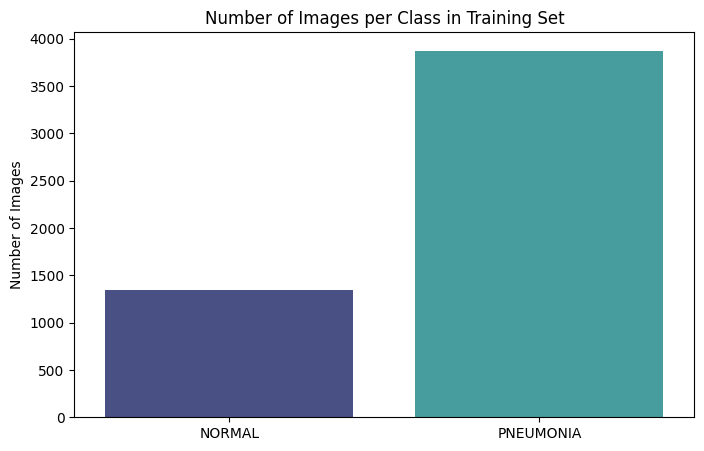

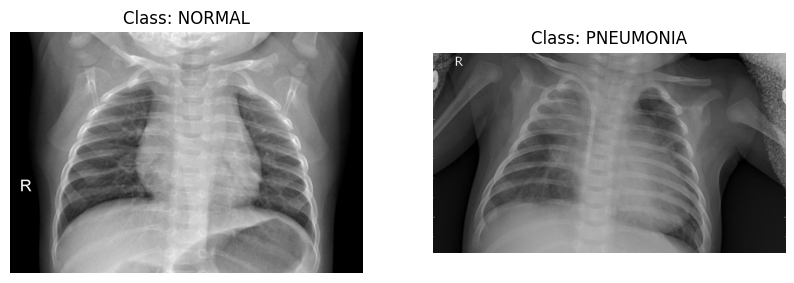

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import numpy as np
classes = ['NORMAL', 'PNEUMONIA']
train_counts = [len(os.listdir(os.path.join(train_dir, c))) for c in classes]

plt.figure(figsize=(8, 5))
sns.barplot(x=classes, y=train_counts, palette='mako')
plt.title('Number of Images per Class in Training Set')
plt.ylabel('Number of Images')
plt.show()


plt.figure(figsize=(10, 5))
for i, c in enumerate(classes):
    folder_path = os.path.join(train_dir, c)
    img_name = os.listdir(folder_path)[0]
    img_path = os.path.join(folder_path, img_name)
    img = cv2.imread(img_path)

    plt.subplot(1, 2, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Class: {c}")
    plt.axis('off')
plt.show()

We visualized the data using Seaborn graphs to check the balance between 'Normal' and 'Pneumonia' images. Then, we plotted a few grayscale X-ray samples just to make sure everything was loaded correctly and looking sharp.

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

print("Loading Training Data:")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("\nLoading Validation Data:")
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("\nLoading Testing Data:")
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Loading Training Data:
Found 5216 images belonging to 2 classes.

Loading Validation Data:
Found 16 images belonging to 2 classes.

Loading Testing Data:
Found 624 images belonging to 2 classes.


To stop this model from just memorizing the images (overfitting), you brought in the ImageDataGenerator.we  applied some clever augmentations to the training data—like slight zooms and rotations. This forces the model to actually learn the visual features of the disease, not just memorize the exact pixels. For the validation and test sets, we kept it strictly to rescaling (1./255) so the evaluation remains fair.

In [9]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Model setup complete!")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Model setup complete!


In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_densenet_model.keras', monitor='val_loss', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)

epochs = 10

print("Training in progress")
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=[early_stopping, checkpoint, reduce_lr]
)
print("Training Done")

Training in progress
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 148s 727ms/step - accuracy: 0.8579 - loss: 0.3252 - val_accuracy: 0.8125 - val_loss: 0.3865 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 623ms/step - accuracy: 0.8984 - loss: 0.2375 - val_accuracy: 0.8125 - val_loss: 0.3861 - learning_rate: 0.0010
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 615ms/step - accuracy: 0.9074 - loss: 0.2371 - val_accuracy: 0.6875 - val_loss: 0.6083 - learning_rate: 0.0010
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 614ms/step - accuracy: 0.9045 - loss: 0.2294 - val_accuracy: 0.6875 - val_loss: 0.6256 - learning_rate: 0.0010
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 98s 604ms/step - accuracy: 0.9122 - loss: 0.2144 - val_accuracy: 0.7500 - val_loss: 0.5368 - learning_rate: 2.0000e-04
Training Done


5.DenseNet121 model

6.Training (Using Callbacks)
When it came to training :

EarlyStopping: To automatically stop the training if the model stops improving, saving you time and preventing overfitting.

ModelCheckpoint: To save the absolute best version of your model's weights so nothing gets lost.

ReduceLROnPlateau: To drop the learning rate if the model gets stuck, helping it catch those fine, complex details.

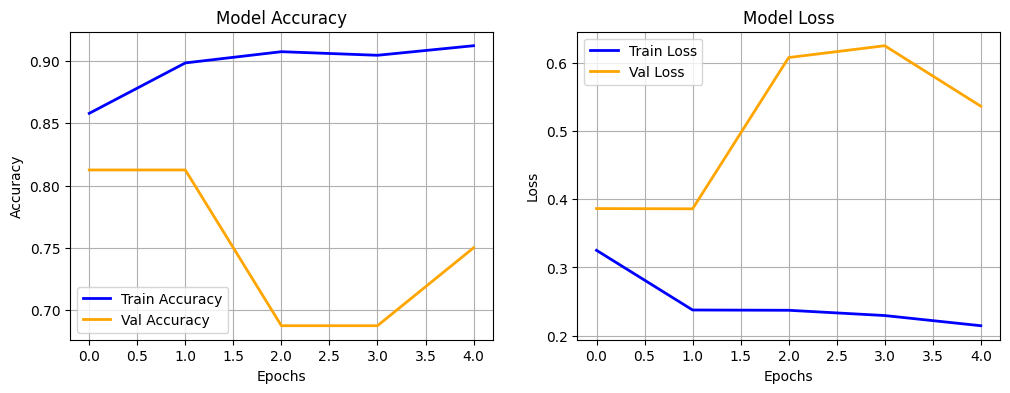


 Evaluating on Test Data:
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 249ms/step - accuracy: 0.8750 - loss: 0.2952
🎯 Test Accuracy: 87.50%
📉 Test Loss: 0.2952


In [11]:
plt.figure(figsize=(12, 4))


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='orange', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()


print("\n Evaluating on Test Data:")
test_loss, test_accuracy = model.evaluate(test_generator)
print(f" Test Accuracy: {test_accuracy * 100:.2f}%")
print(f" Test Loss: {test_loss:.4f}")

we plotted the Accuracy and Loss graphs to see how the model learned across the epochs. Then came the moment of truth: evaluating the model on the unseen Test data to get the real-world accuracy score and make sure it actually performs well on new images.

In [12]:
!pip install -q gradio

import gradio as gr
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing.image import img_to_array

def predict_image(image):

    image = image.resize((224, 224))
    img_array = img_to_array(image)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0


    prediction = model.predict(img_array)[0][0]


    if prediction > 0.5:
        return {"Pneumonia ": float(prediction), "Normal ": float(1 - prediction)}
    else:
        return {"Normal ": float(1 - prediction), "Pneumonia ": float(prediction)}


interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=2),
    title="Chest X-Ray Pneumonia Detector",
    description="This model tests whether you have pneumonia or not , just upload your xray."
)

interface.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://f0e1f6d43332595ca1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://f0e1f6d43332595ca1.gradio.live


finally , simple ui with gradio.